In [1]:
# Lab 01: Feature Engineering & Signal Validation
# **Objective:** Ingest raw market data, process it through the production `LivePipeline`, and rigorously evaluate the feature space for predictive power (IC), stationarity, and collinearity.

import sys
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestClassifier
import time

# Ensure we can import from the core project directory
sys.path.append(os.path.abspath('..'))
from live_pipeline import LivePipeline
from features import feature_manifest

warnings.filterwarnings('ignore')
plt.style.use('dark_background') # Institutional dark mode


In [2]:
# [Markdown]
# ### 1. Feature Generation (Production Parity)

data_path = '../data/processed/gbpusd_15m.parquet'
try:
    raw_df = pd.read_parquet(data_path)
    print(f"✅ Raw Data Loaded: {raw_df.shape[0]} rows, {raw_df.shape[1]} columns")
    
    # ❗️ FIX: Берем только последние 3 года (около 100 000 свечей для 15m)
    # Этого более чем достаточно для проверки Information Coefficient
    raw_df = raw_df.iloc[-100000:].copy()
    print(f"✂️ Data Truncated for Lab Analysis: {raw_df.shape[0]} rows")
    
except FileNotFoundError:
    print(f"❌ File not found at {data_path}.")
    raw_df = pd.DataFrame()

# Запуск пайплайна с замером времени
pipeline = LivePipeline(macro_path='../data/processed/sentiment_embeddings.parquet')

print("⏳ Начало расчета фичей (это может занять 1-3 минуты на 100k строк)...")
start_time = time.time()

processed_df = pipeline.process_live_data(raw_df)

end_time = time.time()
print(f"✅ Pipeline Execution Complete in {end_time - start_time:.2f} seconds.")
print(f"📊 Processed Tensor Shape: {processed_df.shape[0]} rows, {processed_df.shape[1]} columns")

✅ Raw Data Loaded: 803136 rows, 5 columns
✂️ Data Truncated for Lab Analysis: 100000 rows
⚡ Инициализация Low-Latency Pipeline (Статический Граф)
⏳ Начало расчета фичей (это может занять 1-3 минуты на 100k строк)...


Model is not converging.  Current: 442469.9275982827 is not greater than 442546.4803323014. Delta is -76.55273401871091


✅ Pipeline Execution Complete in 31.18 seconds.
📊 Processed Tensor Shape: 100000 rows, 504 columns


In [3]:
# [Markdown]
# ### 2. Target Engineering
# We define our target variable. For a 15m Intraday strategy, we want to predict the smoothed forward momentum over the next 4 bars (1 Hour).

target_horizon = 4

# Calculate forward returns (Log return over the next 'target_horizon' bars)
processed_df['fwd_return_1h'] = np.log(processed_df['close'].shift(-target_horizon) / processed_df['close'])

# For classification/meta-labeling baseline (1 = UP, 0 = DOWN)
processed_df['target_dir_1h'] = np.where(processed_df['fwd_return_1h'] > 0, 1, 0)

# Drop NaNs created by shifting
evaluation_df = processed_df.dropna(subset=['fwd_return_1h']).copy()
print(f"Target distribution (UP vs DOWN):\n{evaluation_df['target_dir_1h'].value_counts(normalize=True) * 100}")

Target distribution (UP vs DOWN):
target_dir_1h
0    64.07533
1    35.92467
Name: proportion, dtype: float64


In [4]:
# [Markdown]
# ### 3. Information Coefficient (IC) Analysis
# We use Spearman Rank Correlation to evaluate the monotonic relationship.

# 1. Dynamically find all numeric columns (ignore strings/objects automatically)
numeric_df = evaluation_df.select_dtypes(include=[np.number])

# 2. Exclude OHLCV, targets, and macro embeddings
# Safely exclude columns only if they actually exist in the DataFrame
base_exclude = ['open', 'high', 'low', 'close', 'volume', 'fwd_return_1h', 'target_dir_1h', 'active_session_name', 'markov_regime']
exclude_cols = [c for c in base_exclude if c in evaluation_df.columns]
macro_cols = [c for c in numeric_df.columns if 'macro_emb' in c]
feature_cols = [c for c in numeric_df.columns if c not in exclude_cols + macro_cols]

ic_results = {}
for col in feature_cols:
    try:
        # Calculate Spearman Rank Correlation
        corr, pval = spearmanr(numeric_df[col], numeric_df['fwd_return_1h'])
        ic_results[col] = {'IC': corr, 'p_value': pval}
    except Exception as e:
        pass

ic_df = pd.DataFrame(ic_results).T
ic_df['Abs_IC'] = ic_df['IC'].abs()
ic_df = ic_df.sort_values(by='Abs_IC', ascending=False)

print("🏆 Top 10 Features by Information Coefficient (Linear/Monotonic Predictive Power)")
display(ic_df.head(10))

🏆 Top 10 Features by Information Coefficient (Linear/Monotonic Predictive Power)


,IC,p_value,Abs_IC
dist_to_pdl,-0.024202,1.951466e-14,0.024202
struct_trend,-0.022659,7.739999e-13,0.022659
linreg_score,-0.020672,6.269490e-11,0.020672
pdl_sweep,0.018421,5.704147e-09,0.018421
dist_to_liq_high,0.017997,1.261143e-08,0.017997
day_cos,0.016833,1.019960e-07,0.016833
trend_1h,-0.016200,3.010492e-07,0.016200
premium_discount,-0.016145,3.300449e-07,0.016145
eql_active,0.014997,2.113137e-06,0.014997
dist_to_liq_low,-0.014439,4.972950e-06,0.014439


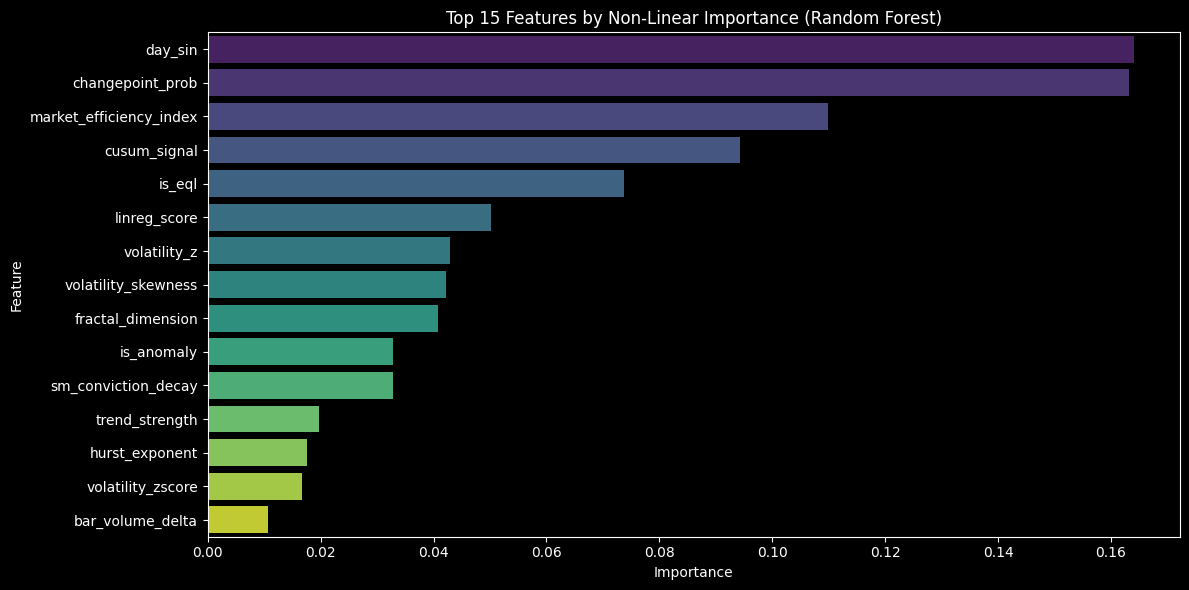

In [5]:
# [Markdown]
# ### 4. Non-Linear Feature Importance (Tree-Based)
# Random Forest acts as a proxy for non-linear interactions.

# X now strictly uses the dynamically filtered numeric feature columns
X = evaluation_df[feature_cols].fillna(0)
y = evaluation_df['target_dir_1h']

# Train a quick RF model
rf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 Features by Non-Linear Importance (Random Forest)')
plt.tight_layout()
plt.show()

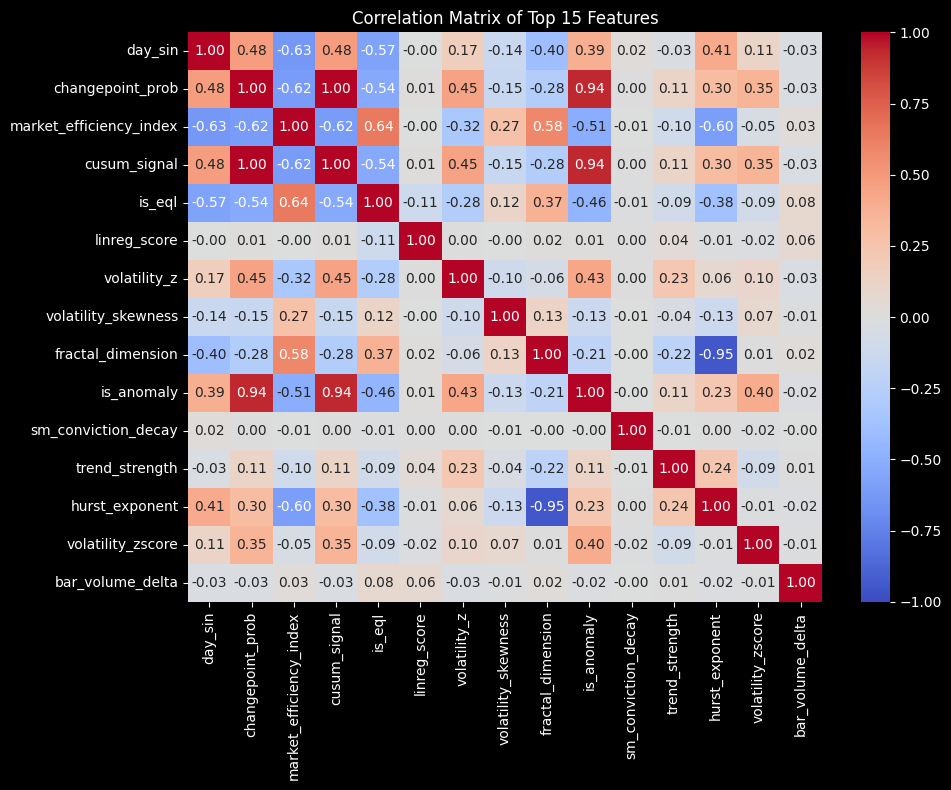

In [6]:
# [Markdown]
# ### 5. Collinearity Check
# Highly correlated features confuse models and waste compute. We want orthogonal signals.

top_features = importance_df['Feature'].head(15).tolist()
corr_matrix = evaluation_df[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Top 15 Features')
plt.tight_layout()
plt.show()

# [Markdown]
# **Next Steps:** If any two features have a correlation > 0.85 (e.g., `dist_to_pdh` and `dist_to_pwh`), consider dropping one or using PCA in the pipeline to orthogonalize them.

In [7]:
# [Markdown]
# ### 6. Automated Multicollinearity Pruning (The "Thunderdome" Protocol)
# This algorithm groups highly correlated features (absolute correlation > 0.70) 
# and automatically drops the weaker ones based on a combined score of IC and RF Importance.

def auto_prune_features(corr_matrix, ic_df, importance_df, threshold=0.70):
    print(f"🔍 Starting Auto-Pruning Protocol (Correlation Threshold: {threshold})\n" + "="*60)
    
    # 1. Build the Scoring Board
    scores = pd.DataFrame(index=corr_matrix.columns)
    
    # Rank IC (Higher is better)
    scores['ic_rank'] = ic_df['Abs_IC'].rank(ascending=True) 
    
    # Rank Importance (Higher is better)
    imp_indexed = importance_df.set_index('Feature')
    scores['rf_rank'] = imp_indexed['Importance'].rank(ascending=True)
    
    # The ultimate survival score
    scores['total_score'] = scores['ic_rank'].fillna(0) + scores['rf_rank'].fillna(0)
    
    # 2. Extract upper triangle of correlation matrix to avoid duplicate comparisons
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    to_drop = set()
    
    # 3. Resolve Clusters
    for col in upper_tri.columns:
        # Find all features that are highly correlated with 'col'
        highly_correlated_peers = upper_tri.index[upper_tri[col].abs() > threshold].tolist()
        
        for peer in highly_correlated_peers:
            if col in to_drop or peer in to_drop:
                continue # One of them is already dead
                
            score_col = scores.loc[col, 'total_score']
            score_peer = scores.loc[peer, 'total_score']
            corr_val = upper_tri.loc[peer, col]
            
            # The Thunderdome match
            if score_col < score_peer:
                print(f"⚔️ MATCH: [{peer}] vs [{col}] (Corr: {corr_val:.2f}) -> 🏆 [{peer}] wins!")
                to_drop.add(col)
            else:
                print(f"⚔️ MATCH: [{col}] vs [{peer}] (Corr: {corr_val:.2f}) -> 🏆 [{col}] wins!")
                to_drop.add(peer)
                
    features_to_keep = [c for c in corr_matrix.columns if c not in to_drop]
    
    print("="*60)
    print(f"🗑️ Features Scheduled for Deletion ({len(to_drop)}):")
    for f in sorted(list(to_drop)):
        print(f"  ❌ {f}")
        
    print(f"\n✅ Orthogonal Features Kept ({len(features_to_keep)}):")
    for f in sorted(features_to_keep):
        print(f"  ✔️ {f}")
        
    return list(to_drop), features_to_keep

# Execute the pruning protocol on our top 15 features
top_features = importance_df['Feature'].head(15).tolist()
corr_matrix_top = evaluation_df[top_features].corr()

dropped_features, orthogonal_features = auto_prune_features(
    corr_matrix=corr_matrix_top,
    ic_df=ic_df,
    importance_df=importance_df,
    threshold=0.70
)

# Create the final, pristine dataset for the Transformer
final_tensor_df = evaluation_df.drop(columns=dropped_features)
print(f"\n🚀 Final Tensor ready for Quantformer: {final_tensor_df.shape[1]} columns.")

🔍 Starting Auto-Pruning Protocol (Correlation Threshold: 0.7)
⚔️ MATCH: [changepoint_prob] vs [cusum_signal] (Corr: 1.00) -> 🏆 [changepoint_prob] wins!
⚔️ MATCH: [is_anomaly] vs [changepoint_prob] (Corr: 0.94) -> 🏆 [is_anomaly] wins!
⚔️ MATCH: [fractal_dimension] vs [hurst_exponent] (Corr: -0.95) -> 🏆 [fractal_dimension] wins!
🗑️ Features Scheduled for Deletion (3):
  ❌ changepoint_prob
  ❌ cusum_signal
  ❌ hurst_exponent

✅ Orthogonal Features Kept (12):
  ✔️ bar_volume_delta
  ✔️ day_sin
  ✔️ fractal_dimension
  ✔️ is_anomaly
  ✔️ is_eql
  ✔️ linreg_score
  ✔️ market_efficiency_index
  ✔️ sm_conviction_decay
  ✔️ trend_strength
  ✔️ volatility_skewness
  ✔️ volatility_z
  ✔️ volatility_zscore

🚀 Final Tensor ready for Quantformer: 503 columns.


In [9]:
# [Markdown]
# ### 7. Global Feature Pruning (Full Space Elimination)
# We now apply the Thunderdome protocol to the ENTIRE feature set, not just the top 15.
# We use a strict threshold of 0.65 to heavily penalize multicollinearity and reduce dimensionality.

# 1. Get ALL continuous features (we already defined 'feature_cols' earlier)
all_continuous_features = [c for c in feature_cols if c in evaluation_df.columns]

# 2. Calculate the massive correlation matrix for all features
print(f"Calculating full {len(all_continuous_features)}x{len(all_continuous_features)} correlation matrix. This may take a few seconds...")
full_corr_matrix = evaluation_df[all_continuous_features].corr()

# 3. Run the Auto-Pruner on the full matrix with a 0.65 threshold
global_dropped, global_kept = auto_prune_features(
    corr_matrix=full_corr_matrix,
    ic_df=ic_df,
    importance_df=importance_df,
    threshold=0.65
)

# 4. Re-attach necessary columns (Targets, Categoricals, and Macro Embeddings)
# We must keep these regardless of correlation because they are structural or targets
must_keep_cols = ['open', 'high', 'low', 'close', 'volume', 
                  'fwd_return_1h', 'target_dir_1h', 
                  'active_session_name', 'markov_regime']
macro_cols = [c for c in evaluation_df.columns if 'macro_emb' in c]

final_columns = must_keep_cols + macro_cols + global_kept

# 5. Build the Final Production Tensor
final_tensor_df = evaluation_df[final_columns].copy()

print("\n" + "="*60)
print(f"🚀 GLOBAL PRUNING COMPLETE")
print(f"Original Feature Count: {len(all_continuous_features)}")
print(f"Features Dropped: {len(global_dropped)}")
print(f"Orthogonal Features Kept: {len(global_kept)}")
print(f"Total Columns in Final Tensor (incl. macro & targets): {final_tensor_df.shape[1]}")
print("="*60)

# Save the pristine tensor for Notebook 02
final_tensor_df.to_parquet('../data/processed/clean_tensor.parquet')
print("💾 Saved pristine tensor to '../data/processed/clean_tensor.parquet'")


Calculating full 113x113 correlation matrix. This may take a few seconds...
🔍 Starting Auto-Pruning Protocol (Correlation Threshold: 0.65)
⚔️ MATCH: [structural_low] vs [structural_high] (Corr: 0.95) -> 🏆 [structural_low] wins!
⚔️ MATCH: [structural_low] vs [swing_high] (Corr: 0.89) -> 🏆 [structural_low] wins!
⚔️ MATCH: [structural_low] vs [swing_low] (Corr: 0.90) -> 🏆 [structural_low] wins!
⚔️ MATCH: [premium_discount] vs [dist_to_liq_low] (Corr: 0.65) -> 🏆 [premium_discount] wins!
⚔️ MATCH: [bar_volume_delta] vs [log_return] (Corr: 0.80) -> 🏆 [bar_volume_delta] wins!
⚔️ MATCH: [structural_low] vs [pdh] (Corr: 0.73) -> 🏆 [structural_low] wins!
⚔️ MATCH: [dist_to_pdl] vs [pdl] (Corr: -0.73) -> 🏆 [dist_to_pdl] wins!
⚔️ MATCH: [dist_to_pwl] vs [pwl] (Corr: -0.76) -> 🏆 [dist_to_pwl] wins!
⚔️ MATCH: [eql_active] vs [is_eql] (Corr: 0.68) -> 🏆 [eql_active] wins!
⚔️ MATCH: [dist_to_pwh] vs [trend_1d] (Corr: -0.66) -> 🏆 [dist_to_pwh] wins!
⚔️ MATCH: [linreg_score] vs [norm_slope] (Corr: 0.71) 